In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ------------------------
# STEP 1: Load actuals
# ------------------------
historical_data = pd.read_excel("/content/SaaS_Startup_Financials.xlsx")
historical_data["Source"] = "Actual"

# ------------------------
# STEP 2: Define Scenarios
# ------------------------
scenarios = {
    "Base": {
        "monthly_new_customers": 130,
        "monthly_churn_rate": 0.045,
        "arpu_growth_rate": 0.01,
    },
    "Best": {
        "monthly_new_customers": 160,
        "monthly_churn_rate": 0.03,
        "arpu_growth_rate": 0.015,
    },
    "Worst": {
        "monthly_new_customers": 100,
        "monthly_churn_rate": 0.06,
        "arpu_growth_rate": 0.005,
    }
}

forecast_months = pd.date_range(start="2025-01-01", periods=12, freq="MS")

# Common assumptions
base_arpu = historical_data["ARPU"].iloc[-1]
starting_customers = historical_data["Customer Base"].iloc[-1]
cogs_pct = 0.18
cogs_noise = 0.01
r_and_d_base = 32000
r_and_d_growth = 0.01
s_and_m_base = 42000
s_and_m_growth = 0.015
g_and_a_base = 21000
g_and_a_growth = 0.01
da_base = 3200
interest = 1000
tax_rate = 0.25

# ------------------------
# STEP 3: Generate Forecasts
# ------------------------
all_forecasts = []

for scenario_name, params in scenarios.items():
    customers = [starting_customers]
    arpu = [base_arpu * (1 + params["arpu_growth_rate"])]
    for i in range(1, 12):
        retained = customers[-1] * (1 - params["monthly_churn_rate"])
        customers.append(retained + params["monthly_new_customers"])
        arpu.append(arpu[-1] * (1 + params["arpu_growth_rate"]))

    revenue = np.array(customers) * np.array(arpu)
    cogs = revenue * (cogs_pct + np.random.normal(0, cogs_noise, 12))
    r_and_d = [r_and_d_base * (1 + r_and_d_growth) ** i for i in range(12)]
    s_and_m = [s_and_m_base * (1 + s_and_m_growth) ** i for i in range(12)]
    g_and_a = [g_and_a_base * (1 + g_and_a_growth) ** i for i in range(12)]
    ebitda = revenue - cogs - r_and_d - s_and_m - g_and_a
    da = [da_base] * 12
    ebit = ebitda - da
    tax = [e * tax_rate if e > 0 else 0 for e in ebit]
    net_income = ebit - da - interest - tax

    forecast = pd.DataFrame({
        "Date": forecast_months,
        "Customer Base": np.round(customers),
        "ARPU": np.round(arpu, 2),
        "Revenue": np.round(revenue, 2),
        "COGS": np.round(cogs, 2),
        "R&D": np.round(r_and_d, 2),
        "Sales & Marketing": np.round(s_and_m, 2),
        "G&A": np.round(g_and_a, 2),
        "EBITDA": np.round(ebitda, 2),
        "D&A": da,
        "EBIT": np.round(ebit, 2),
        "Interest": interest,
        "Tax": np.round(tax, 2),
        "Net Income": np.round(net_income, 2),
        "Source": scenario_name
    })
    all_forecasts.append(forecast)

# ------------------------
# STEP 4: Combine All Data
# ------------------------
forecast_df = pd.concat(all_forecasts, ignore_index=True)
combined_df = pd.concat([historical_data, forecast_df], ignore_index=True)

# ------------------------
# STEP 5: Visualize & Export to PDF
# ------------------------
pdf_path = "Forecast_Report_2025.pdf"
with PdfPages(pdf_path) as pdf:
    # Revenue
    plt.figure(figsize=(10, 6))
    for label, df in combined_df.groupby("Source"):
        plt.plot(df["Date"], df["Revenue"], label=f"{label} Revenue")
    plt.title("Revenue: Actuals and Scenarios")
    plt.xlabel("Month")
    plt.ylabel("Revenue ($)")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # EBITDA & Net Income
    plt.figure(figsize=(10, 6))
    for label, df in combined_df.groupby("Source"):
        plt.plot(df["Date"], df["EBITDA"], label=f"{label} EBITDA", linestyle='--')
        plt.plot(df["Date"], df["Net Income"], label=f"{label} Net Income", linestyle='-')
    plt.title("EBITDA & Net Income: Actuals and Scenarios")
    plt.xlabel("Month")
    plt.ylabel("Amount ($)")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # Customer Base
    plt.figure(figsize=(10, 6))
    for label, df in combined_df.groupby("Source"):
        plt.plot(df["Date"], df["Customer Base"], label=f"{label} Customers")
    plt.title("Customer Base: Actuals and Forecast Scenarios")
    plt.xlabel("Month")
    plt.ylabel("Customer Count")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

print(f"PDF report saved to: {pdf_path}")


PDF report saved to: Forecast_Report_2025.pdf


In [4]:
import pandas as pd
import numpy as np

# ----------------------------
# STEP 1: Load Actuals
# ----------------------------
historical_data = pd.read_excel("/content/SaaS_Startup_Financials.xlsx")
historical_data["Source"] = "Actual"

# ----------------------------
# STEP 2: Define Base Assumptions
# ----------------------------
assumptions = {
    "monthly_new_customers": 130,
    "monthly_churn_rate": 0.045,
    "arpu_growth_rate": 0.01,
}

# Constants
base_arpu = historical_data["ARPU"].iloc[-1]
starting_customers = historical_data["Customer Base"].iloc[-1]
forecast_months = pd.date_range(start="2025-01-01", periods=12, freq="MS")

cogs_pct = 0.18
cogs_noise = 0.01
r_and_d_base = 32000
r_and_d_growth = 0.01
s_and_m_base = 42000
s_and_m_growth = 0.015
g_and_a_base = 21000
g_and_a_growth = 0.01
da_base = 3200
interest = 1000
tax_rate = 0.25

# ----------------------------
# STEP 3: Generate Forecast
# ----------------------------
customers = [starting_customers]
arpu = [base_arpu * (1 + assumptions["arpu_growth_rate"])]

for i in range(1, 12):
    retained = customers[-1] * (1 - assumptions["monthly_churn_rate"])
    customers.append(retained + assumptions["monthly_new_customers"])
    arpu.append(arpu[-1] * (1 + assumptions["arpu_growth_rate"]))

revenue = np.array(customers) * np.array(arpu)
cogs = revenue * (cogs_pct + np.random.normal(0, cogs_noise, 12))
r_and_d = [r_and_d_base * (1 + r_and_d_growth) ** i for i in range(12)]
s_and_m = [s_and_m_base * (1 + s_and_m_growth) ** i for i in range(12)]
g_and_a = [g_and_a_base * (1 + g_and_a_growth) ** i for i in range(12)]
ebitda = revenue - cogs - r_and_d - s_and_m - g_and_a
da = [da_base] * 12
ebit = ebitda - da
tax = [e * tax_rate if e > 0 else 0 for e in ebit]
net_income = ebit - da - interest - tax

forecast = pd.DataFrame({
    "Date": forecast_months,
    "Customer Base": np.round(customers),
    "ARPU": np.round(arpu, 2),
    "Revenue": np.round(revenue, 2),
    "COGS": np.round(cogs, 2),
    "R&D": np.round(r_and_d, 2),
    "Sales & Marketing": np.round(s_and_m, 2),
    "G&A": np.round(g_and_a, 2),
    "EBITDA": np.round(ebitda, 2),
    "D&A": da,
    "EBIT": np.round(ebit, 2),
    "Interest": interest,
    "Tax": np.round(tax, 2),
    "Net Income": np.round(net_income, 2),
    "Source": "Forecast"
})

# ----------------------------
# STEP 4: Combine & Export
# ----------------------------
combined_df = pd.concat([historical_data, forecast], ignore_index=True)
combined_df.to_excel("Actuals_and_Forecast_2023_2025.xlsx", index=False)

print("Excel file created: Actuals_and_Forecast_2023_2025.xlsx")


Excel file created: Actuals_and_Forecast_2023_2025.xlsx


INFO:prophet:n_changepoints greater than number of observations. Using 18.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpefiu5dg6/euvuscpi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpefiu5dg6/ze1671zv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=42677', 'data', 'file=/tmp/tmpefiu5dg6/euvuscpi.json', 'init=/tmp/tmpefiu5dg6/ze1671zv.json', 'output', 'file=/tmp/tmpefiu5dg6/prophet_modelozlz185u/prophet_model-20250415044111.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:41:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:41:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


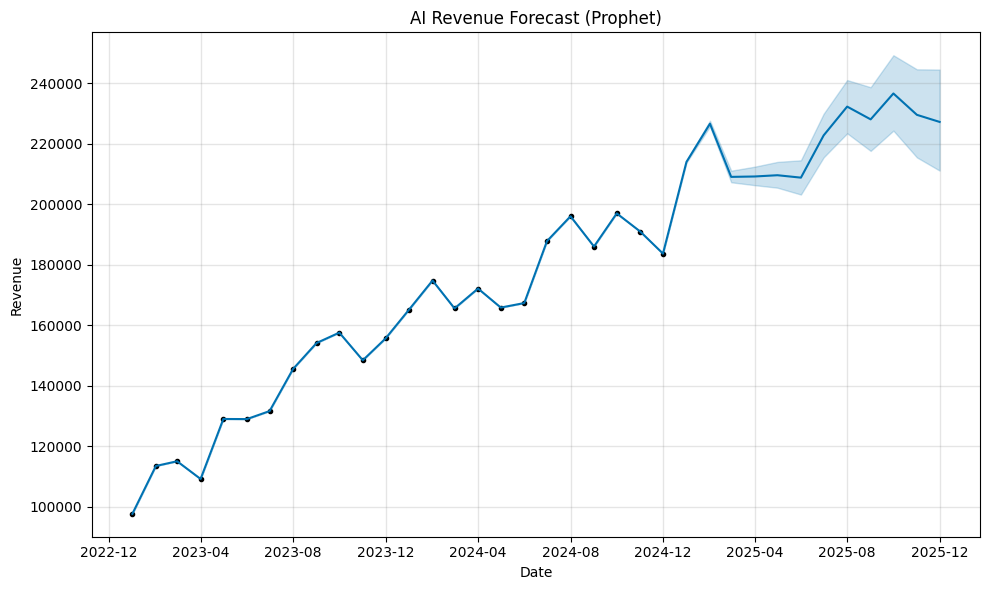

Forecast saved as 'Revenue_Forecast_AI.xlsx'


In [6]:
# First install Prophet if you haven't:
#pip install prophet

import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load historical data (update path as needed)
historical_data = pd.read_excel("SaaS_Startup_Financials.xlsx")

# Prepare data for Prophet
df = historical_data[["Date", "Revenue"]].copy()
df.rename(columns={"Date": "ds", "Revenue": "y"}, inplace=True)

# Initialize model
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df)

# Forecast next 12 months
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

# Plot forecast
fig = model.plot(forecast)
plt.title("AI Revenue Forecast (Prophet)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Export forecast to Excel
output = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
output.rename(columns={"ds": "Date", "yhat": "Forecast Revenue"}, inplace=True)
output.to_excel("Revenue_Forecast_AI.xlsx", index=False)
print("Forecast saved as 'Revenue_Forecast_AI.xlsx'")


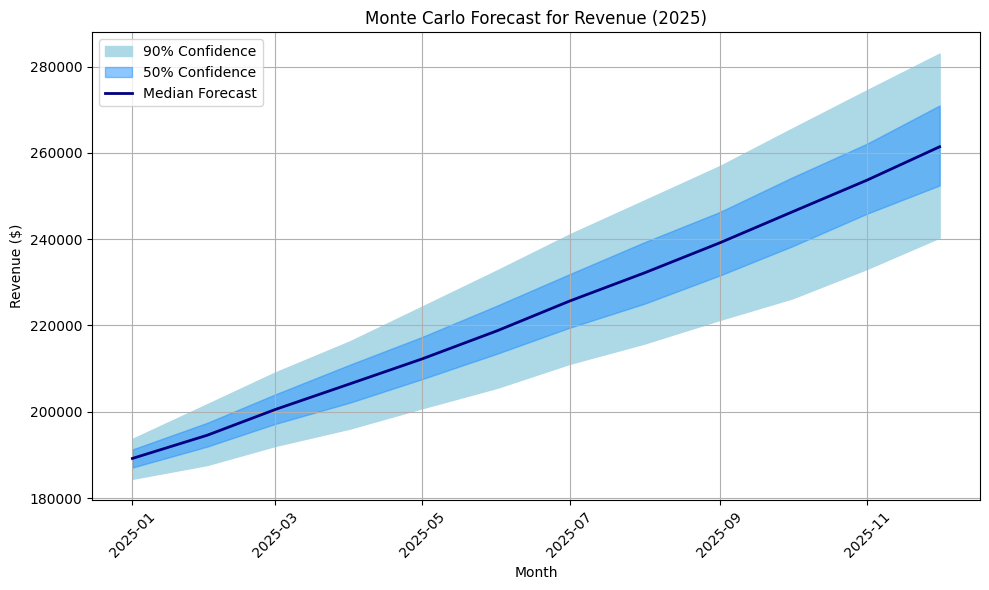

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load historical data
historical_data = pd.read_excel("SaaS_Startup_Financials.xlsx")

# Parameters for simulation
n_simulations = 1000
forecast_months = 12
last_revenue = float(historical_data["Revenue"].iloc[-1])

# Simulation assumptions
mean_growth_rate = 0.03  # 3% monthly growth
std_dev = 0.015          # 1.5% volatility

# Run simulations
simulated_revenues = np.zeros((forecast_months, n_simulations))
for i in range(n_simulations):
    growth = np.random.normal(loc=mean_growth_rate, scale=std_dev, size=forecast_months)
    sim = [last_revenue * (1 + growth[0])]
    for j in range(1, forecast_months):
        sim.append(sim[-1] * (1 + growth[j]))
    simulated_revenues[:, i] = sim

# Percentiles for confidence intervals
percentiles = np.percentile(simulated_revenues, [5, 25, 50, 75, 95], axis=1)

# Dates and DataFrame
dates = pd.date_range(start="2025-01-01", periods=forecast_months, freq="MS")
monte_carlo_df = pd.DataFrame({
    "Date": dates,
    "P5": percentiles[0],
    "P25": percentiles[1],
    "Median": percentiles[2],
    "P75": percentiles[3],
    "P95": percentiles[4],
})

# Plot
plt.figure(figsize=(10, 6))
plt.fill_between(monte_carlo_df["Date"], monte_carlo_df["P5"], monte_carlo_df["P95"], color='lightblue', label='90% Confidence')
plt.fill_between(monte_carlo_df["Date"], monte_carlo_df["P25"], monte_carlo_df["P75"], color='dodgerblue', alpha=0.5, label='50% Confidence')
plt.plot(monte_carlo_df["Date"], monte_carlo_df["Median"], color='navy', linewidth=2, label='Median Forecast')
plt.title("Monte Carlo Forecast for Revenue (2025)")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: Save to Excel
monte_carlo_df.to_excel("MonteCarlo_RevenueForecast_2025.xlsx", index=False)


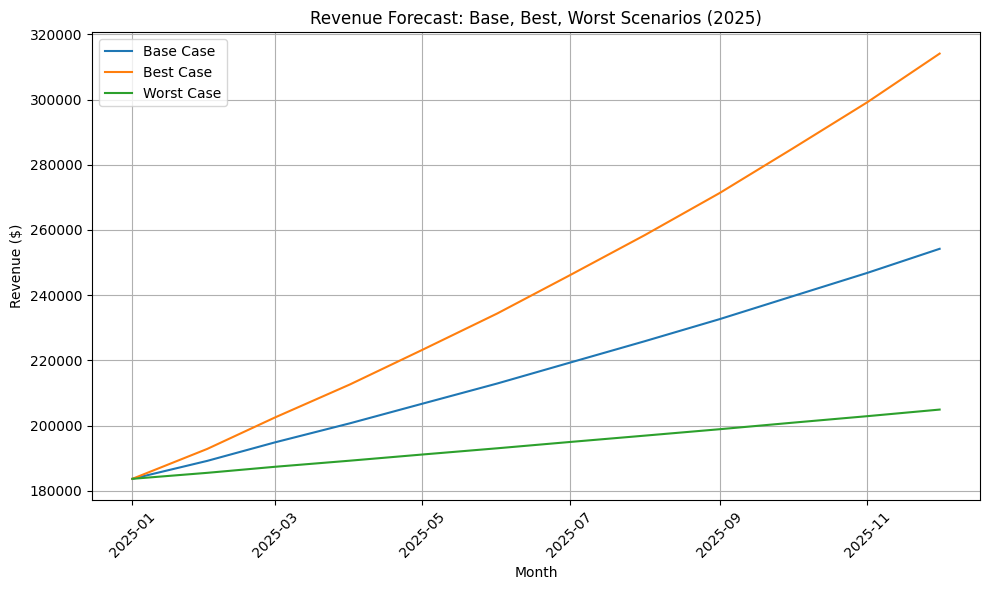

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load historical data
historical_data = pd.read_excel("SaaS_Startup_Financials.xlsx")
last_revenue = float(historical_data["Revenue"].iloc[-1])

# Forecast setup
forecast_months = 12
dates = pd.date_range(start="2025-01-01", periods=forecast_months, freq="MS")

# Define scenarios
scenarios = {
    "Base": {"growth_rate": 0.03},
    "Best": {"growth_rate": 0.05},
    "Worst": {"growth_rate": 0.01}
}

# Build forecasts
scenario_df = pd.DataFrame({"Date": dates})

for name, params in scenarios.items():
    revenue = [last_revenue]
    for _ in range(1, forecast_months):
        revenue.append(revenue[-1] * (1 + params["growth_rate"]))
    scenario_df[name] = revenue

# Plot
plt.figure(figsize=(10, 6))
for name in scenarios:
    plt.plot(scenario_df["Date"], scenario_df[name], label=f"{name} Case")

plt.title("Revenue Forecast: Base, Best, Worst Scenarios (2025)")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: Export to Excel
scenario_df.to_excel("Scenario_RevenueForecast_2025.xlsx", index=False)
